# Feature Enginnering - Tratamento de Outliers: The Movies Dataset
Nesta etapa, fazemos a transição oficial do diagnóstico visual (EDA) para a engenharia de dados. Com base nas análises anteriores, já sabemos que os valores extremos do nosso dataset representam a realidade da indústria cinematográfica:

* **Os Fenômenos (Outliers de Negócio):** Obras de altíssimo impacto (*Blockbusters*) que puxam as métricas de engajamento (`total_votes`) e finanças (`revenue`, `budget`) para a extrema direita.

###  Roteiro de Ação:
1. **Validação Estatística (Quick Look):** Aplicaremos o cálculo do IQR (Intervalo Interquartil) para confirmar matematicamente as fronteiras que observamos na exploração visual.
2. **Tratamento Definitivo (Cirurgia):** * Preservaremos os fenômenos de mercado criando *flags* categóricas (Feature Engineering, ex: `is_blockbuster`), garantindo que o sucesso absoluto da obra não seja deletado nem envieze modelos futuros.

In [1]:
# Configuração do Jupyter (Autoreload)
%load_ext autoreload
%autoreload 2

# Configuração de Caminho (Path Setup)
import sys
import os

# Adiciona a pasta raiz do projeto (..) ao sistema para liberar os imports locais
sys.path.append(os.path.abspath(os.path.join('..')))

# Importação de Bibliotecas e Módulos
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Módulos customizados da pasta src/
import src.io.data_loader as dl
import src.io.data_save as ds
import src.utils.metrics as mt
import src.view.plots as graf
import src.view.tables as tb
import src.utils.features as feat

---

## Carregando Dados

In [5]:
caminho = '../data/interim/movies/movies_enriched.parquet'
df_movies = dl.load_data(file_path=caminho, tipo_arquivo='parquet')

Dados Parquet carregados! Formato: (41091, 22)


In [2]:
colunas_explodidas = ['genres', 'producer_company', 'production_countries', 'spoken_languages']
dfs_exploded = []

dfs_exploded = [
    dl.load_data(
        file_path=f"../data/interim/movies/movies_{coluna.split('_')[-1]}.parquet",
        tipo_arquivo='parquet'
    )
    for coluna in colunas_explodidas
]
     

Dados Parquet carregados! Formato: (86933, 22)
Dados Parquet carregados! Formato: (77006, 22)
Dados Parquet carregados! Formato: (50882, 22)
Dados Parquet carregados! Formato: (52356, 22)


---
## Análise de Outliers 

In [6]:
dict_total_votes = {
    'cerca': None,
    'df_outliers': None
}

dict_total_votes['cerca'], dict_total_votes['df_outliers'] = mt.calcular_metricas_outliers(
    df_movies, 'total_votes'
)

Primeiro Quartil (Q1): 4.00
Terceiro Quartil (Q3): 40.00
Limite Estatístico (Cerca Superior): 94.00
Total de Outliers Detectados: 6215 de 41091 (15.12%)


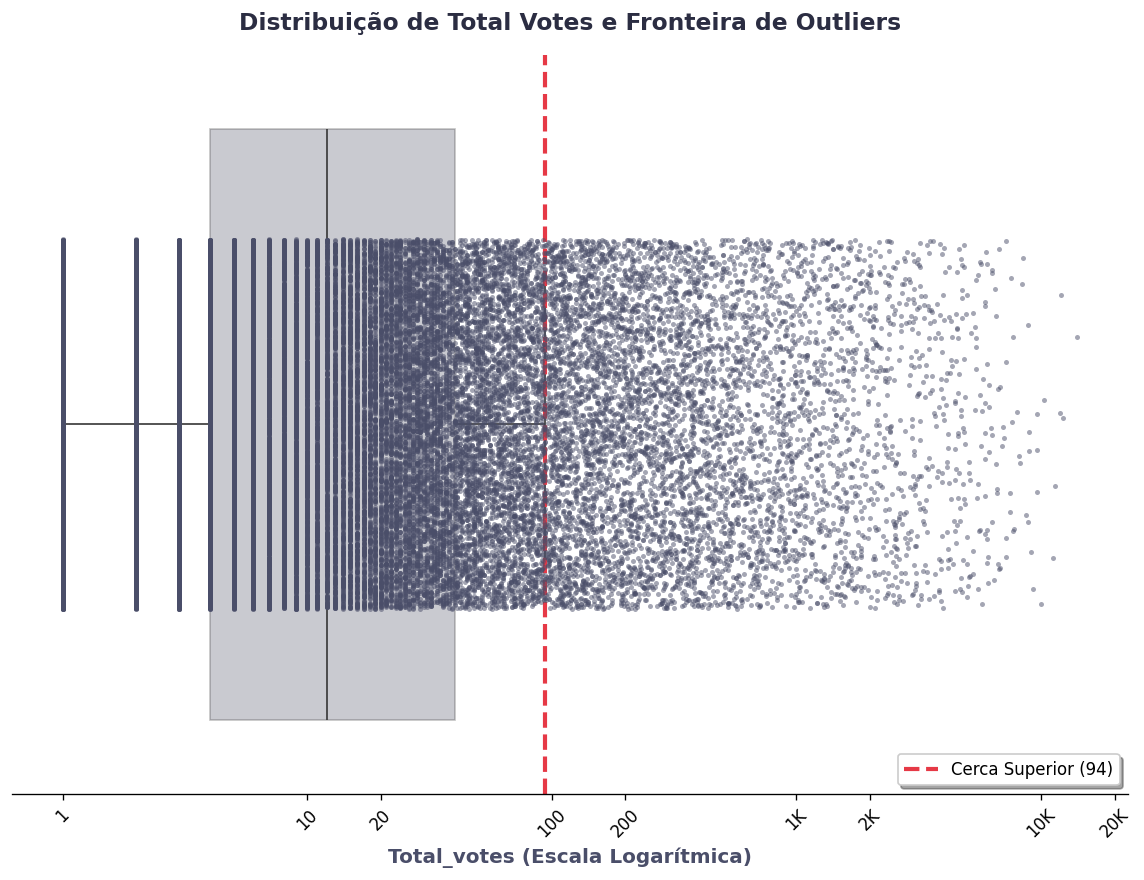

In [7]:
graf.plotar_fronteira_outliers(
    df_plot=df_movies,
    coluna='total_votes',
    cerca_superior=dict_total_votes['cerca'],
    usar_log=True,
    tipo_dado='contagem_centena_milhar'
)

In [8]:
display(tb.estilizar_tabela(
    df=dict_total_votes['df_outliers']
        .sort_values(
            by='total_votes', 
            ascending=False
        ),
    qtd_linhas=5,
    colunas_selecionadas=['title', 'total_votes', 'popularity_tier'],
    caption="Top 5 Títulos que puxam a cauda para a direita:"
))

,title,total_votes,popularity_tier
15055,Inception,"14,075",Mainstream Hit
12179,The Dark Knight,"12,269",Mainstream Hit
14172,Avatar,"12,114",Mainstream Hit
17246,The Avengers,"12,000",Mainstream Hit
25094,Deadpool,"11,444",Mainstream Hit


In [9]:
dict_revenue = {
    'cerca': None,
    'df_outliers': None
}

dict_revenue['cerca'], dict_revenue['df_outliers'] = mt.calcular_metricas_outliers(
    df_movies, 'revenue'
)

Primeiro Quartil (Q1): 2,494,480.00
Terceiro Quartil (Q3): 68,129,518.00
Limite Estatístico (Cerca Superior): 166,582,075.00
Total de Outliers Detectados: 831 de 41091 (2.02%)


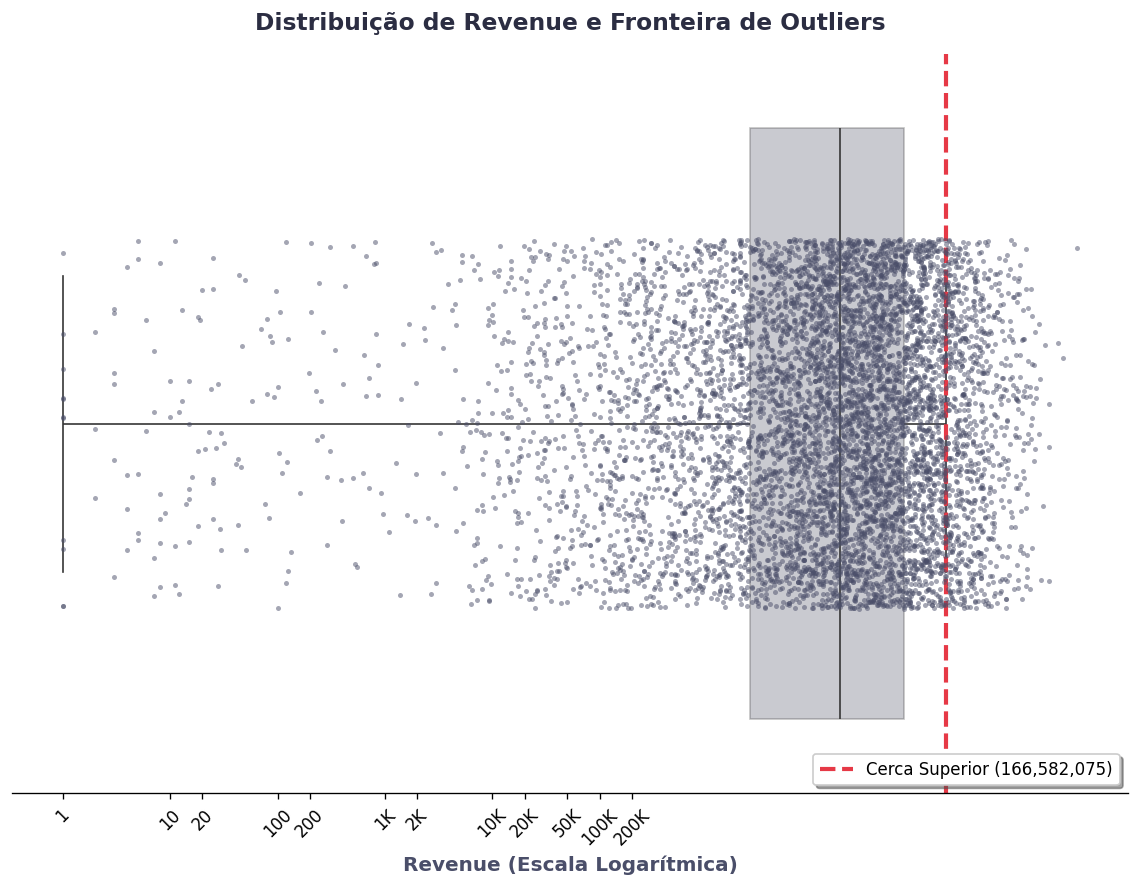

In [17]:
graf.plotar_fronteira_outliers(
    df_plot=df_movies,
    coluna='revenue',
    cerca_superior=dict_revenue['cerca'],
    usar_log=True,
    tipo_dado='contagem_centena_milhar'
)

In [26]:
display(tb.estilizar_tabela(
    df=dict_revenue['df_outliers']
        .sort_values(
            by='revenue', 
            ascending=False
        ),
    qtd_linhas=10,
    colunas_selecionadas=['title', 'revenue', 'popularity_tier'],
    caption="Top 10 Filmes com Maior Renda:"
))

,title,revenue,popularity_tier
14172,Avatar,"US$ 2,787,965,087",Mainstream Hit
25087,Star Wars: The Force Awakens,"US$ 2,068,223,624",Mainstream Hit
1553,Titanic,"US$ 1,845,034,188",Mainstream Hit
17246,The Avengers,"US$ 1,519,557,910",Mainstream Hit
23792,Jurassic World,"US$ 1,513,528,810",Mainstream Hit
27109,Furious 7,"US$ 1,506,249,360",Mainstream Hit
25090,Avengers: Age of Ultron,"US$ 1,405,403,694",Mainstream Hit
16888,Harry Potter and the Deathly Hallows: Part 2,"US$ 1,342,000,000",Mainstream Hit
21129,Frozen,"US$ 1,274,219,009",Mainstream Hit
38372,Beauty and the Beast,"US$ 1,262,886,337",Mainstream Hit


In [27]:
display(tb.estilizar_tabela(
    df=dict_revenue['df_outliers']
        .sort_values(
            by='revenue', 
            ascending=True
        ),
    qtd_linhas=10,
    colunas_selecionadas=['title', 'revenue', 'popularity_tier'],
    caption="Top 10 Filmes com Menor Renda:"
))

,title,revenue,popularity_tier
18428,Magic Mike,"US$ 167,221,571",Mainstream Hit
8004,Alexander,"US$ 167,298,192",Mass Appeal
7592,DodgeBall: A True Underdog Story,"US$ 167,722,310",Mainstream Hit
15648,Unstoppable,"US$ 167,805,466",Mainstream Hit
25093,Fantastic Four,"US$ 167,977,596",Mass Appeal
12882,Seven Pounds,"US$ 168,167,691",Mainstream Hit
31,Twelve Monkeys,"US$ 168,840,000",Mainstream Hit
3742,The Emperor's New Groove,"US$ 169,327,687",Mainstream Hit
11435,Meet the Robinsons,"US$ 169,332,978",Mainstream Hit
38436,Ghost in the Shell,"US$ 169,801,921",Mass Appeal


In [15]:
dict_budget = {
    'cerca': None,
    'df_outliers': None
}

dict_budget['cerca'], dict_budget['df_outliers'] = mt.calcular_metricas_outliers(
    df_movies, 'budget'
)

Primeiro Quartil (Q1): 2,000,000.00
Terceiro Quartil (Q3): 25,697,387.00
Limite Estatístico (Cerca Superior): 61,243,467.50
Total de Outliers Detectados: 812 de 41091 (1.98%)


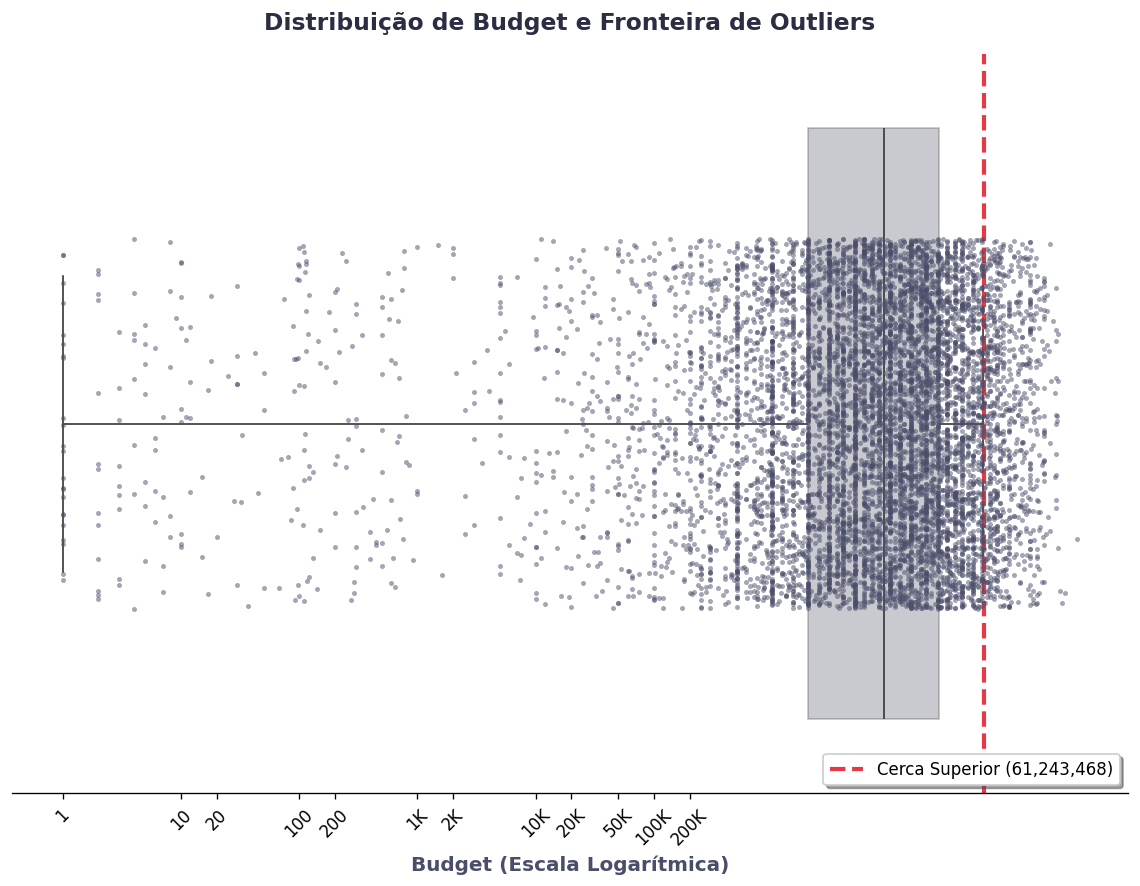

In [18]:
graf.plotar_fronteira_outliers(
    df_plot=df_movies,
    coluna='budget',
    cerca_superior=dict_budget['cerca'],
    usar_log=True,
    tipo_dado='contagem_centena_milhar'
)

In [24]:
display(tb.estilizar_tabela(
    df=dict_budget['df_outliers']
        .sort_values(
            by='budget', 
            ascending=False
        ),
    qtd_linhas=10,
    colunas_selecionadas=['title', 'budget', 'popularity_tier'],
    caption="Top 10 Filmes Maior Orçamento:"
))

,title,budget,popularity_tier
16605,Pirates of the Caribbean: On Stranger Tides,"US$ 380,000,000",Mainstream Hit
11533,Pirates of the Caribbean: At World's End,"US$ 300,000,000",Mainstream Hit
25090,Avengers: Age of Ultron,"US$ 280,000,000",Mainstream Hit
10780,Superman Returns,"US$ 270,000,000",Mass Appeal
15663,Tangled,"US$ 260,000,000",Mainstream Hit
18038,John Carter,"US$ 260,000,000",Mainstream Hit
40574,Transformers: The Last Knight,"US$ 260,000,000",Mainstream Hit
11487,Spider-Man 3,"US$ 258,000,000",Mass Appeal
20281,The Lone Ranger,"US$ 255,000,000",Mass Appeal
25096,Captain America: Civil War,"US$ 250,000,000",Mainstream Hit


In [25]:
display(tb.estilizar_tabela(
    df=dict_budget['df_outliers']
        .sort_values(
            by='budget', 
            ascending=True
        ),
    qtd_linhas=10,
    colunas_selecionadas=['title', 'budget', 'popularity_tier'],
    caption="Top 10 Filmes com Menor Orçamento:"
))

,title,budget,popularity_tier
10,The American President,"US$ 62,000,000",Mainstream Hit
3882,3000 Miles to Graceland,"US$ 62,000,000",Mass Appeal
12147,The Love Guru,"US$ 62,000,000",Mass Appeal
3292,U-571,"US$ 62,000,000",Mainstream Hit
6346,Matchstick Men,"US$ 62,000,000",Mainstream Hit
335,Clear and Present Danger,"US$ 62,000,000",Mainstream Hit
1817,Lolita,"US$ 62,000,000",Mainstream Hit
10093,Æon Flux,"US$ 62,000,000",Mass Appeal
2723,Fight Club,"US$ 63,000,000",Mainstream Hit
16408,Hop,"US$ 63,000,000",Mass Appeal


In [29]:
# Filtrando os filmes suspeitos (excluindo os zeros, que já sabemos que são nulos disfarçados)
suspeitos_budget = df_movies[(df_movies['budget'] > 0) & (df_movies['budget'] < 5000)]
suspeitos_revenue = df_movies[(df_movies['revenue'] > 0) & (df_movies['revenue'] < 5000)]

In [30]:
# Exibindo os casos mais críticos de Orçamento
display(tb.estilizar_tabela(
    df=suspeitos_budget
        .sort_values(
            by='budget'
    ),
    colunas_selecionadas=['title', 'budget', 'revenue', 'popularity_tier'],
    qtd_linhas=10,
    caption="Filmes com Orçamento irreal (Entre $1 e $4.999)"
))

,title,budget,revenue,popularity_tier
876,East of Eden,US$ 1,US$ 5,Mainstream Hit
2088,Slam,US$ 1,nan,Hidden Gem / Cult
3203,Modern Times,US$ 1,"US$ 8,500,000",Mainstream Hit
2373,Lost & Found,US$ 1,US$ 100,Mass Appeal
3849,Less Than Zero,US$ 1,"US$ 12,396,383",Mainstream Hit
9556,Incident at Loch Ness,US$ 1,nan,Mass Appeal
15014,Cool Air,US$ 1,nan,Nicho
12718,"Angus, Thongs and Perfect Snogging",US$ 1,nan,Mainstream Hit
20411,Fetching Cody,US$ 1,nan,Hidden Gem / Cult
15423,Tere Naam,US$ 1,US$ 2,Mainstream Hit


In [31]:
# Exibindo os casos mais críticos de Receita
display(tb.estilizar_tabela(
    df=suspeitos_revenue
        .sort_values(
            by='budget'
    ),
    colunas_selecionadas=['title', 'budget', 'revenue', 'popularity_tier'],
    qtd_linhas=10,
    caption="Filmes com Receita irreal (Entre $1 e $4.999)"
))

,title,budget,revenue,popularity_tier
876,East of Eden,US$ 1,US$ 5,Mainstream Hit
2373,Lost & Found,US$ 1,US$ 100,Mass Appeal
18567,"Love, Wedding, Marriage",US$ 1,"US$ 1,378",Mass Appeal
15423,Tere Naam,US$ 1,US$ 2,Mainstream Hit
35277,Saamy,US$ 1,US$ 3,Nicho
32500,The Letters,US$ 1,US$ 1,Nicho
174,Mute Witness,US$ 2,US$ 1,Mainstream Hit
11886,No Mercy for the Rude,US$ 3,US$ 4,Mainstream Hit
27725,Falling From Grace,US$ 3,US$ 232,Nicho
16400,Boy,US$ 3,US$ 43,Mainstream Hit
